In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # 1. 첫 번째 합성곱 층 (Convolution Layer)
        # 입력 채널: 1 (흑백 이미지), 출력 채널: 6, 커널 크기: 3x3, 패딩: 1 (28x28 크기 유지)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1)
        
        # 2. 첫 번째 풀링 층 (Pooling Layer: 28x28 -> 14x14)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 3. 두 번째 합성곱 층 (Convolution Layer)
        # 입력 채널: 6, 출력 채널: 16, 커널 크기: 3x3, 패딩: 1 (14x14 크기 유지)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1, padding=1)
        
        # 4. 두 번째 풀링 층 (Pooling Layer: 14x14 -> 7x7)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 5. 완전 연결 층 (Fully Connected / Linear Layers)
        # 최종 특성 맵 크기: 16채널 * 7 * 7 = 784
        self.fc1 = nn.Linear(16 * 7 * 7, 120)
        self.fc2 = nn.Linear(120, 10)  # 최종 출력 클래스 개수: 10개 (0~9 숫자 분류)

    def forward(self, x):
        # [특성 추출 부 - Feature Extraction]
        # 입력 이미지 -> Conv1 -> ReLU -> MaxPool1 (28x28 -> 14x14)
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        # Conv2 -> ReLU -> MaxPool2 (14x14 -> 7x7)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        # 선형 결합(Fully Connected)을 위해 차원 펼치기 (Flatten)
        x = x.view(-1, 16 * 7 * 7)
        
        # [분류 부 - Classification]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        # Softmax 활성화 함수 적용 (확률 값 출력)
        output = F.softmax(x, dim=1)
        
        return output

# 모델 인스턴스 생성
model = CNN()
print(model)

# 테스트용 더미 입력 데이터 생성 (Batch Size: 1, Channels: 1, Height: 28, Width: 28)
dummy_input = torch.randn(1, 1, 28, 28)
output = model(dummy_input)

print("\n출력 결과 형태 (Shape):", output.shape)
print("출력 확률 값:", output)

CNN(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=10, bias=True)
)

출력 결과 형태 (Shape): torch.Size([1, 10])
출력 확률 값: tensor([[0.1059, 0.1053, 0.1028, 0.0987, 0.1062, 0.0894, 0.1052, 0.0811, 0.1112,
         0.0941]], grad_fn=<SoftmaxBackward0>)


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# ==========================================
# 1. 학습 장치(Device) 설정
# ==========================================
# GPU(CUDA)가 사용 가능한 경우 GPU를 활용하고, 그렇지 않으면 CPU를 사용하도록 설정합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==========================================
# 2. MNIST 데이터셋 전처리 및 로드 (Data Loading & Preprocessing)
# ==========================================
# 이미지를 텐서로 변환하고, 평균(0.1307)과 표준편차(0.3081)를 이용해 정규화(Normalize)를 수행합니다.
transform = transforms.Compose([
    transforms.ToTensor(),                          # 이미지를 PyTorch Tensor 형태로 변환 (0~1 범위)
    transforms.Normalize((0.1307,), (0.3081,))      # MNIST 데이터셋의 통계값으로 정규화하여 학습 안정화
])

# 학습용 MNIST 데이터셋 다운로드 및 로드
train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)
# 미니배치 단위로 데이터를 묶어주고 셔플(Shuffle)을 적용하여 학습용 데이터로더 생성
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, 
    batch_size=64, 
    shuffle=True
)

# 테스트용 MNIST 데이터셋 다운로드 및 로드
test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)
# 테스트용 데이터로더 생성 (평가용이므로 셔플은 필요 없음)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, 
    batch_size=1000, 
    shuffle=False
)


# ==========================================
# 3. CNN (합성곱 신경망) 모델 아키텍처 정의
# ==========================================
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # [첫 번째 합성곱 층]
        # 입력 채널: 1 (흑백 이미지), 출력 채널: 6, 커널 크기: 3x3, 패딩: 1 (입력 크기 28x28 유지)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1)
        
        # [첫 번째 풀링 층]
        # 2x2 최대 풀링(Max Pooling)을 통해 특성 맵의 공간 크기를 절반으로 축소 (28x28 -> 14x14)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # [두 번째 합성곱 층]
        # 입력 채널: 6, 출력 채널: 16, 커널 크기: 3x3, 패딩: 1 (입력 크기 14x14 유지)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1, padding=1)
        
        # [두 번째 풀링 층]
        # 2x2 최대 풀링을 통해 특성 맵의 크기를 다시 절반으로 축소 (14x14 -> 7x7)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # [완전 연결 층 (Fully Connected Layers)]
        # 최종 특성 맵 크기: 16채널 × 7 × 7 = 784
        self.fc1 = nn.Linear(16 * 7 * 7, 120)  # 은닉층 (784 -> 120)
        self.fc2 = nn.Linear(120, 10)           # 출력층 (120 -> 10, 0~9 숫자 분류)

    def forward(self, x):
        # ----------------------------------
        # 특성 추출 부 (Feature Extraction)
        # ----------------------------------
        # 1. 첫 번째 Conv -> ReLU 활성화 함수 -> Max Pooling (28x28 -> 14x14)
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        # 2. 두 번째 Conv -> ReLU 활성화 함수 -> Max Pooling (14x14 -> 7x7)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        # 3. 다차원 특성 맵을 1차원 벡터로 평탄화 (Flatten) -> Fully Connected 층 입력을 위함
        x = x.view(-1, 16 * 7 * 7)
        
        # ----------------------------------
        # 분류 부 (Classification)
        # ----------------------------------
        # 4. 첫 번째 전결합층 + ReLU 활성화 함수
        x = F.relu(self.fc1(x))
        
        # 5. 최종 출력층 (원시 로짓 값 반환, CrossEntropyLoss에 의해 내부적으로 Softmax 처리됨)
        x = self.fc2(x)
        return x


# 모델 인스턴스를 생성하고 지정한 장치(GPU 또는 CPU)로 이동
model = CNN().to(device)


# ==========================================
# 4. 손실 함수(Loss Function) 및 옵티마이저(Optimizer) 설정
# ==========================================
criterion = nn.CrossEntropyLoss()                 # 다중 클래스 분류를 위한 교차 엔트로피 손실 함수
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 옵티마이저 (학습률: 0.001)


# ==========================================
# 5. 모델 학습 (Training Loop)
# ==========================================
num_epochs = 3  # 전체 데이터셋을 학습할 횟수(에폭) 설정

model.train()  # 모델을 학습 모드로 설정
for epoch in range(num_epochs):
    running_loss = 0.0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        # 데이터를 지정된 장치(GPU/CPU)로 전송
        data, target = data.to(device), target.to(device)
        
        # 1. 이전 단계에서 계산된 옵티마이저의 기울기(Gradient)를 0으로 초기화
        optimizer.zero_grad()
        
        # 2. 순전파(Forward Pass): 모델에 입력을 넣어 예측값(출력) 계산
        output = model(data)
        
        # 3. 손실(Loss) 계산: 예측값과 실제 정답(target) 간의 오차 산출
        loss = criterion(output, target)
        
        # 4. 역전파(Backward Pass): 오차에 대한 기울기 계산
        loss.backward()
        
        # 5. 가중치 갱신(Optimizer Step): 계산된 기울기를 바탕으로 모델 파라미터 업데이트
        optimizer.step()
        
        # 로그 출력 및 손실 누적
        running_loss += loss.item()
        if batch_idx % 200 == 199:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {running_loss / 200:.4f}')
            running_loss = 0.0


# ==========================================
# 6. 모델 평가 (Evaluation Loop)
# ==========================================
model.eval()  # 모델을 평가 모드로 설정
correct = 0
total = 0

# 평가 과정에서는 기울기 계산이 필요 없으므로 메모리 절약을 위해 torch.no_grad() 사용
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        
        # 순전파를 통해 예측 결과 도출
        output = model(data)
        
        # 가장 높은 확률을 가진 클래스를 예측값으로 선택
        _, predicted = torch.max(output.data, 1)
        
        # 전체 데이터 개수 및 맞은 개수 누적
        total += target.size(0)
        correct += (predicted == target).sum().item()

# 최종 테스트 정확도 출력
print(f'\nTest Accuracy of the model on the 10000 test images: {100 * correct / total:.2f}%')

Using device: cpu
Epoch [1/3], Step [200/938], Loss: 0.5535
Epoch [1/3], Step [400/938], Loss: 0.1756
Epoch [1/3], Step [600/938], Loss: 0.1217
Epoch [1/3], Step [800/938], Loss: 0.1058
Epoch [2/3], Step [200/938], Loss: 0.0795
Epoch [2/3], Step [400/938], Loss: 0.0661
Epoch [2/3], Step [600/938], Loss: 0.0702
Epoch [2/3], Step [800/938], Loss: 0.0638
Epoch [3/3], Step [200/938], Loss: 0.0461
Epoch [3/3], Step [400/938], Loss: 0.0479
Epoch [3/3], Step [600/938], Loss: 0.0510
Epoch [3/3], Step [800/938], Loss: 0.0481

Test Accuracy of the model on the 10000 test images: 98.61%


Using device: cpu
-> 입력 이미지 텐서 Shape: torch.Size([64, 1, 28, 28])
-> 정답 레이블 텐서 Shape: torch.Size([64])

--- 모델 학습 및 검증 시작 ---
Epoch [1/5] | Train Loss: 0.1492, Train Acc: 95.33% | Val Loss: 0.0526, Val Acc: 98.39%
Epoch [2/5] | Train Loss: 0.0457, Train Acc: 98.57% | Val Loss: 0.0448, Val Acc: 98.68%
Epoch [3/5] | Train Loss: 0.0305, Train Acc: 98.98% | Val Loss: 0.0457, Val Acc: 98.64%
Epoch [4/5] | Train Loss: 0.0217, Train Acc: 99.27% | Val Loss: 0.0406, Val Acc: 98.84%
Epoch [5/5] | Train Loss: 0.0176, Train Acc: 99.43% | Val Loss: 0.0376, Val Acc: 99.00%


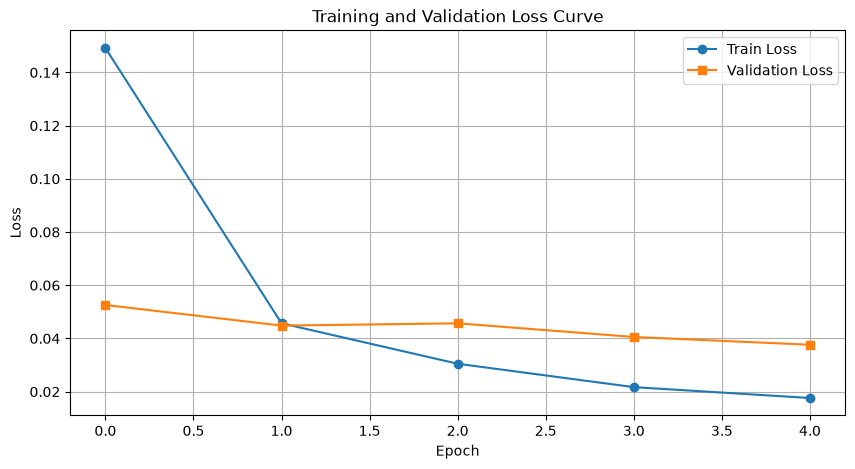


[Test 결과] 최종 테스트 정확도(Accuracy): 99.08%


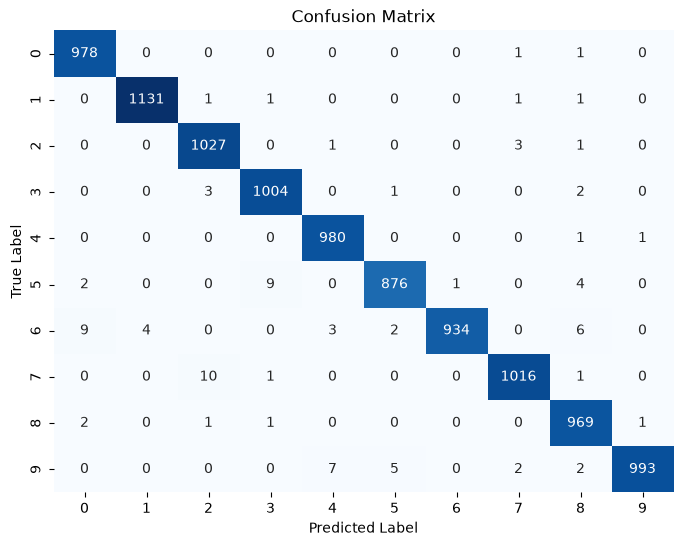


[오분류 분석] 테스트 데이터 중 틀린 이미지 개수: 92개


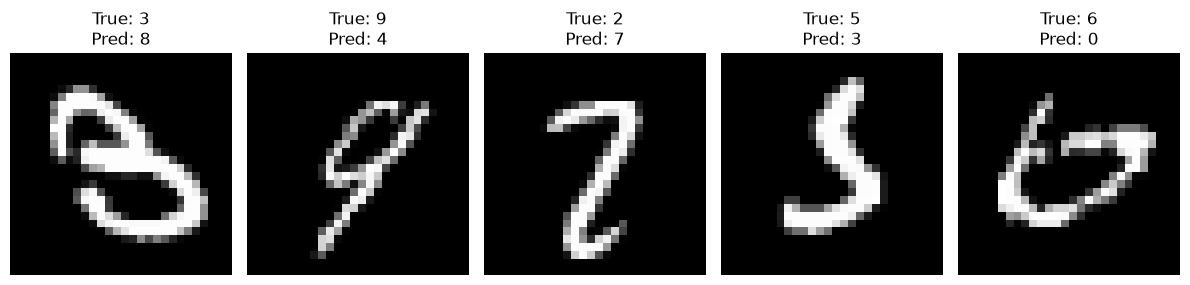


[모델 저장 완료] 학습된 모델 가중치가 'mnist_cnn_model.pth'로 저장되었습니다.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ==========================================
# 1. 학습 장치(Device) 설정
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==========================================
# 2. 전처리 정의 및 MNIST Dataset 로드
# ==========================================
transform = transforms.Compose([
    transforms.ToTensor(),                          # ③ Tensor 변환 (이미지 데이터를 PyTorch Tensor로 변환)
    transforms.Normalize((0.1307,), (0.3081,))      # MNIST 데이터셋의 평균 및 표준편차 정규화
])

# ① MNIST Dataset 로드 (학습/검증용 및 테스트용 데이터셋 다운로드 및 로드)
full_train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)


# ==========================================
# 3. 데이터셋 분할 및 DataLoader 구성
# ==========================================
train_size = 50000
val_size = 10000
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset, [train_size, val_size]
)

# ④ DataLoader 구성 (미니배치 단위 로드)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=1000, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# ② 이미지 데이터 확인 (첫 번째 배치 샘플 형태 출력)
examples = enumerate(train_loader)
batch_idx, (sample_data, sample_targets) = next(examples)
print(f"-> 입력 이미지 텐서 Shape: {sample_data.shape}")
print(f"-> 정답 레이블 텐서 Shape: {sample_targets.shape}")


# ==========================================
# 4. CNN 모델 구현 (Conv, Pooling, FC Layer 구성)
# ==========================================
# ⑤ CNN 모델 구현
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # ⑥ Convolution Layer 구성 및 ⑦ Pooling Layer 구성 (1번째)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # ⑥ Convolution Layer 구성 및 ⑦ Pooling Layer 구성 (2번째)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # ⑧ Fully Connected Layer 구성
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        x = x.view(-1, 64 * 7 * 7)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)


# ==========================================
# 5. Loss Function 및 Optimizer 구성
# ==========================================
criterion = nn.CrossEntropyLoss()                  # ⑨ Loss Function 구성
optimizer = optim.Adam(model.parameters(), lr=0.001)  # ⑩ Optimizer 구성


# ==========================================
# 6. Training Loop 및 Validation 구현
# ==========================================
num_epochs = 5
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("\n--- 모델 학습 및 검증 시작 ---")
for epoch in range(num_epochs):
    # ⑪ Training Loop 구현
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train  # ⑭ Accuracy 계산 (Train)
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # ⑫ Validation 구현
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = 100 * correct_val / total_val  # ⑭ Accuracy 계산 (Validation)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")


# ==========================================
# 7. Loss 시각화
# ==========================================
# ⑮ Loss 시각화
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()


# ==========================================
# 8. Test 구현 및 Accuracy 계산
# ==========================================
# ⑬ Test 구현
model.eval()
correct_test = 0
total_test = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()  # ⑭ Accuracy 계산 (Test)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

test_accuracy = 100 * correct_test / total_test
print(f"\n[Test 결과] 최종 테스트 정확도(Accuracy): {test_accuracy:.2f}%")


# ==========================================
# 9. Confusion Matrix 작성 및 시각화
# ==========================================
# ⑯ Confusion Matrix 작성
conf_matrix = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()


# ==========================================
# 10. 오분류 이미지 분석 (Misclassified Image Analysis)
# ==========================================
# ⑰ 오분류 이미지 분석
all_preds_np = np.array(all_preds)
all_targets_np = np.array(all_targets)
misclassified_idx = np.where(all_preds_np != all_targets_np)[0]

print(f"\n[오분류 분석] 테스트 데이터 중 틀린 이미지 개수: {len(misclassified_idx)}개")

plt.figure(figsize=(12, 5))
for i, idx in enumerate(misclassified_idx[:5]):
    image, true_label = test_dataset[idx]
    pred_label = all_preds_np[idx]
    
    plt.subplot(1, 5, i + 1)
    img_np = image.squeeze().numpy() * 0.3081 + 0.1307
    plt.imshow(img_np, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('misclassified_images.png')
plt.show()


# ==========================================
# 11. 모델 저장 (Model Saving)
# ==========================================
# ⑱ 모델 저장
torch.save(model.state_dict(), 'mnist_cnn_model.pth')
print("\n[모델 저장 완료] 학습된 모델 가중치가 'mnist_cnn_model.pth'로 저장되었습니다.")